## 1. Imports and Hardware Setup

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm.auto import tqdm

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: cuda


In [27]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = './data'
    SAVE_PATH = '/content/drive/MyDrive/DL'
    print("✅ Contected to Google Drive")
except(ValueError, ImportError, Exception) as e:
    print(f"❌ Error: {e}")
    print("❌ Failed to mount to Google Drive --> ✅ Use Local Path")
    DATA_PATH = "./data"
    SAVE_PATH = DATA_PATH

❌ Error: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.
❌ Failed to mount to Google Drive --> ✅ Use Local Path


## 2. Hyperparameters

In [28]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 30

## 3. Dataset Preparation

In [29]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root=DATA_PATH, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_PATH, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. LeNet-5 Model Architecture

In [30]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5), # C1
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # S2

            nn.Conv2d(6, 16, kernel_size=5), # C3
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2), # S4

            nn.Conv2d(16, 120, kernel_size=5), # C5
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Linear(120, 84), # F6
            nn.Tanh(),
            nn.Linear(84, num_classes) # Output
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        out = self.classifier(x)

        return out

model = LeNet5().to(device)
print("✅ Model created")

✅ Model created


## 5. Training Loop

In [31]:
criterion = nn.CrossEntropyLoss()
# Use SGD like in the Paper
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

In [32]:
def train(loader, model, criterion, optimizer):
    # Put the model in train mode
    model.train()
    train_loss, correct = 0, 0
    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()

    return train_loss / len(loader.dataset), correct / len(loader.dataset)


In [33]:
def eval(loader, model, criterion):
    model.eval()
    eval_loss, correct = 0, 0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            eval_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()

    return eval_loss / len(loader.dataset), correct / len(loader.dataset)


In [34]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}


for epoch in range(EPOCHS):
    start_time = time.time() # Start timing

    train_loss, train_acc = train(train_loader, model, criterion, optimizer)
    test_loss, test_acc = eval(test_loader, model, criterion)

    end_time = time.time() # End timing
    duration = end_time - start_time

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Time: {duration:.2f}s "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Training:   0%|          | 0/938 [00:00<?, ?it/s]

Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/30] - Time: 17.67s Train Loss: 2.2707, Train Acc: 0.2360 | Test Loss: 2.2290, Test Acc: 0.3862


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Testing:   0%|          | 0/157 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [29/30] - Time: 17.52s Train Loss: 0.2902, Train Acc: 0.9177 | Test Loss: 0.2740, Test Acc: 0.9229


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Testing:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [30/30] - Time: 17.46s Train Loss: 0.2843, Train Acc: 0.9190 | Test Loss: 0.2680, Test Acc: 0.9257


## 6. Results Visualization

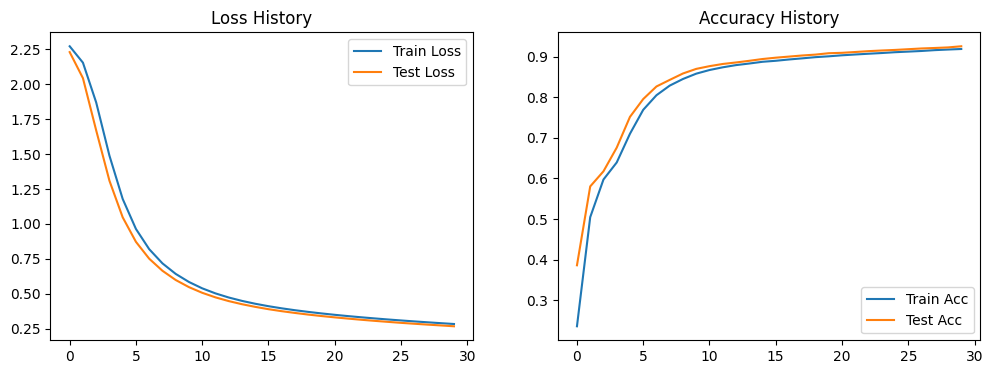

In [35]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

## 7. Model Inference Demo

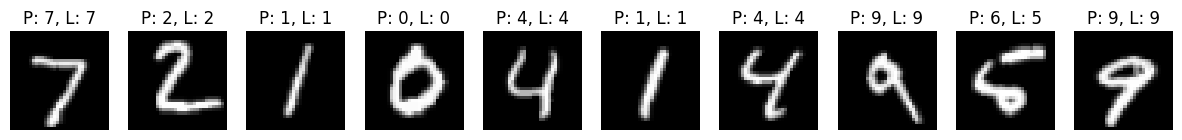

In [37]:
def visualize_inference(model, loader, device, num_images=10):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"P: {preds[i].item()}, L: {labels[i].item()}")
        plt.axis('off')
    plt.show()

visualize_inference(model, test_loader, device)